# Raman Spectroscopy Data Analysis: Combination of Three Amino Acids

This notebook demonstrates the numerical analysis for three amino acids combinations.

## Dataset Overview
- **Source**: Raman spectroscopy measurements of amino acid powders
- **Laser**: 532nm
- **Samples**: Background (blank slide) + 19 amino acids
- **Format**: Tab-separated text files with wavenumber and intensity data

## Import required tools and functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from spectra import SpectraCollection, Spectrum
from spectra import read_spectrum_file, read_simple_spectrum
from spectra import subtract_baseline_arpls, subtract_baseline_als, PreprocessingPipeline, normalize_minmax, calculate_snr, Spectrum
from spectra import calculate_snr, export_to_npz

# Set random seed for reproducible example selection
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

def get_txt_filepath(name, root='./data/batch3'):
    if '+' in name:
        folder = Path(root) / name
    else:
        amino_acid = f'{name[0].upper()}{name[1:]}' if name == 'glycine' else f'L-{name[0].upper()}{name[1:]}'
        folder = Path(root) / amino_acid
    filenames = list(folder.glob(f'*.txt'))

    collection_path = None
    test_spectrum_path = None
    if len(filenames) > 0:
        for filename in filenames:
            if 'test' in filename.stem:
                test_spectrum_path = filename
            if 'power' in filename.stem:
                collection_path = filename
    return collection_path, test_spectrum_path

def get_fingerprint(collection, threshold=50):
    snr = calculate_snr(collection)
    intensities = collection.to_intensity_matrix()
    mean_intensity = intensities[snr>threshold, :].mean(axis=0)
    fingerprint = Spectrum(np.stack((collection.wavelengths, mean_intensity), axis=1))
    return normalize_minmax(fingerprint)

def plot_colletion_and_test_spectrum(collection, test_spectrum, title=' Raman Spectroscopy Data'):
    # visualise raw data
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
    
    if collection:
       mean_intensities = collection.to_intensity_matrix().mean(axis=0)
       ax1.plot(collection.wavelengths, mean_intensities,
               'k-', linewidth=1.5, label='Fingerprint')
        
    if test_spectrum:
        ax1.plot(test_spectrum.wavelengths, test_spectrum.intensities,
                 'g-', linewidth=1.5, alpha=1, label='Test Spectrum')
        
    ax1.set_xlabel('Wavenumber (cm⁻¹)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Data Structure

The spectra package handles two file formats:

### 1. Simple Format (2 columns)
Single spectrum per file with `#Wave` and `#Intensity` columns:
```
#Wave        #Intensity
1925.662109  217.207626
1924.119141  189.444244
...
```

### 2. Mapped Format (4 columns)
Multiple spectra per file with spatial coordinates `#X`, `#Y`, `#Wave`, `#Intensity`:
```
#X            #Y            #Wave        #Intensity
-10007.539247 -13426.202300 1925.662109  129.018066
-10007.539247 -13426.202300 1924.119141  130.651199
...
```

New spectra are detected when the X coordinate changes.

### Key Properties
- **Wavenumber range**: ~157 to ~1925 cm⁻¹
- **Points per spectrum**: 1023
- **Wavelength order**: Stored in ascending order (low to high)

In [2]:
def process_pipeline(name, save_npz = True, save_dir= Path('./data/monopeptide')):
    save_dir = save_dir / name
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # IO: read raw txt files for Raman Sepectroscopy Data
    collection_path, test_spectrum_path = get_txt_filepath(name, root='./data/batch3')
    if collection_path:
        collection = read_spectrum_file(collection_path)
        print(f"{name}: {len(collection)} spectra loaded")
        if save_npz:
            export_to_npz(collection, save_dir / 'raw_data.npz')
            print(f"Saved spectra data at {save_dir / 'raw_data.npz'}")        
    else:
        print(f"{name}: Missing spectra")
    
    if test_spectrum_path:
        test_collection = read_spectrum_file(test_spectrum_path)
        print(f"Test spectrum is loaded for {name}")
        if save_npz:
            export_to_npz(test_collection, save_dir / 'raw_test_spectrum.npz')
            print(f"Saved test spectrum data at {save_dir / 'raw_test_spectrum.npz'}") 
        test_spectrum = test_collection[0]
    else:
        test_spectrum = None
        print(f" Missing test spectrum for {name}")
    
    # Plot the raw data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title=' Raman Spectroscopy Data (RAW)')
    
    # Preprocessing: Baseline correction, Noise removal and min-max normalisaiton
    collection = (PreprocessingPipeline(collection)
        .normalize()                                   # Min-max normalization to [0,1]
        .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
        .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
        .normalize()                                   # Min-max normalization to [0,1]
        .result()
        )
    if save_npz:
        export_to_npz(collection, save_dir / 'data.npz')
        print(f"Saved preprocessed spectra data at {save_dir / 'data.npz'}") 

    if test_spectrum:
        test_spectrum = (PreprocessingPipeline(test_spectrum)
            .normalize()                                   # Min-max normalization to [0,1]
            .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
            .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
            .normalize()                                   # Min-max normalization to [0,1]
            .result()
            )
        
        if save_npz:
            test_collection = SpectraCollection([test_spectrum], source_file=test_spectrum_path)
            export_to_npz(test_collection, save_dir / 'test_spectrum.npz')
            print(f"Saved preprocessed test spectrum data at {save_dir / 'test_spectrum.npz'}")
    
    # Plot the preprocessed data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title='Raman Spectroscopy Data (preprocessed)')
    
    # Fingerprint Generation: filter spectra data based on SNR and select top 100 results for averaging
    fingerprint = get_fingerprint(collection, threshold=50)
    fingerprint_collection = SpectraCollection([fingerprint], source_file=collection_path)
    if save_npz:
        export_to_npz(fingerprint_collection, save_dir / 'fingerprint.npz')
    
    plot_colletion_and_test_spectrum(fingerprint_collection, test_spectrum, title='Raman Spectroscopy Data (SNR>50)')

# Combos with Three Amino Acids

## A+D+F

A+D+F: 1302 spectra loaded
Saved spectra data at data\combos3\A+D+F\raw_data.npz
Test spectrum is loaded for A+D+F
Saved test spectrum data at data\combos3\A+D+F\raw_test_spectrum.npz


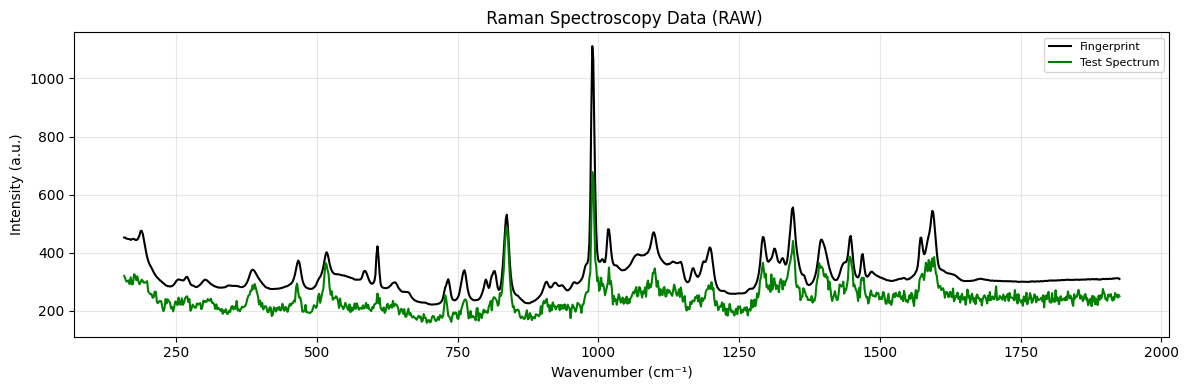

Saved preprocessed spectra data at data\combos3\A+D+F\data.npz
Saved preprocessed test spectrum data at data\combos3\A+D+F\test_spectrum.npz


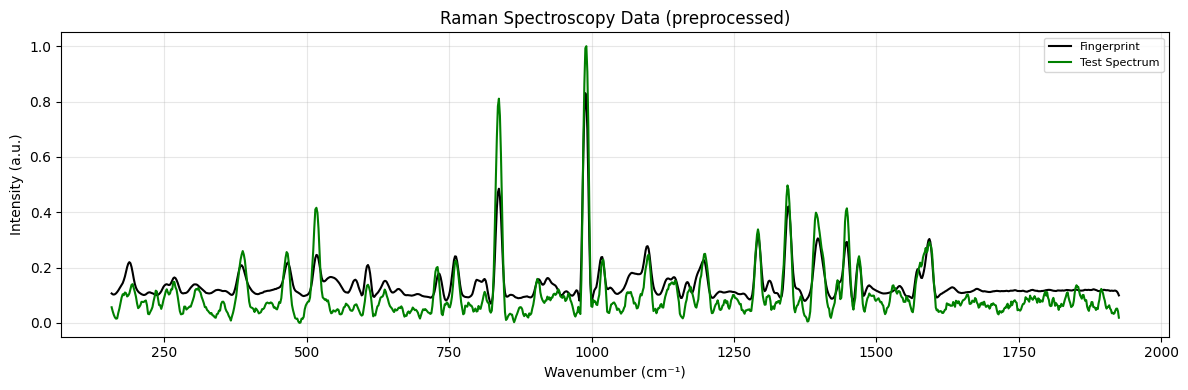

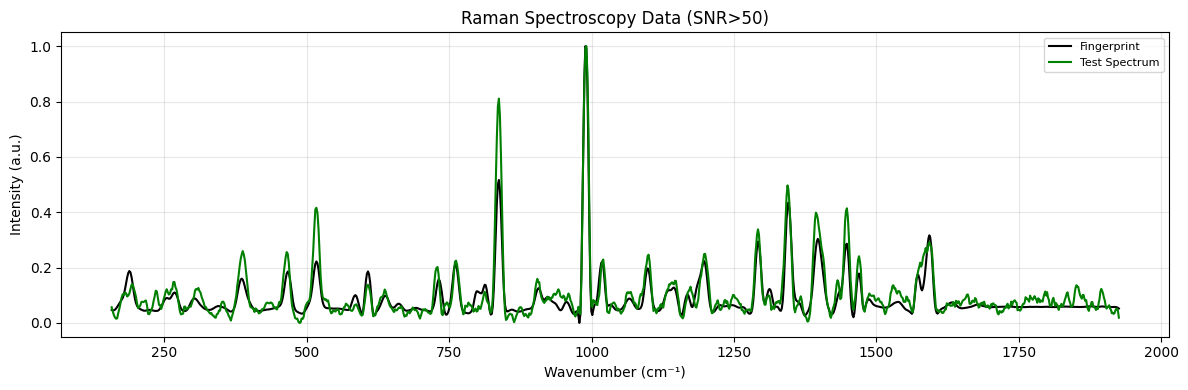

In [3]:
name = 'A+D+F'
process_pipeline(name, save_dir = Path('./data/combos3'))

## A+D+G

A+D+G: 1334 spectra loaded
Saved spectra data at data\combos3\A+D+G\raw_data.npz
Test spectrum is loaded for A+D+G
Saved test spectrum data at data\combos3\A+D+G\raw_test_spectrum.npz


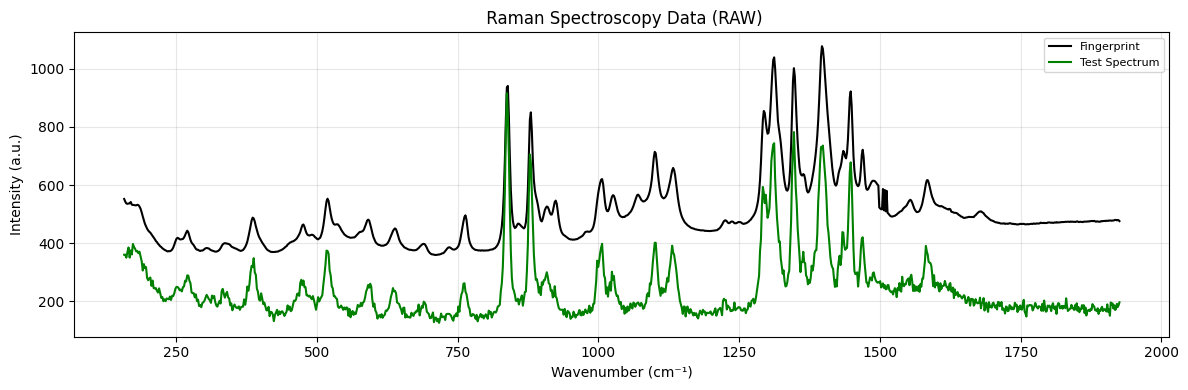

Saved preprocessed spectra data at data\combos3\A+D+G\data.npz
Saved preprocessed test spectrum data at data\combos3\A+D+G\test_spectrum.npz


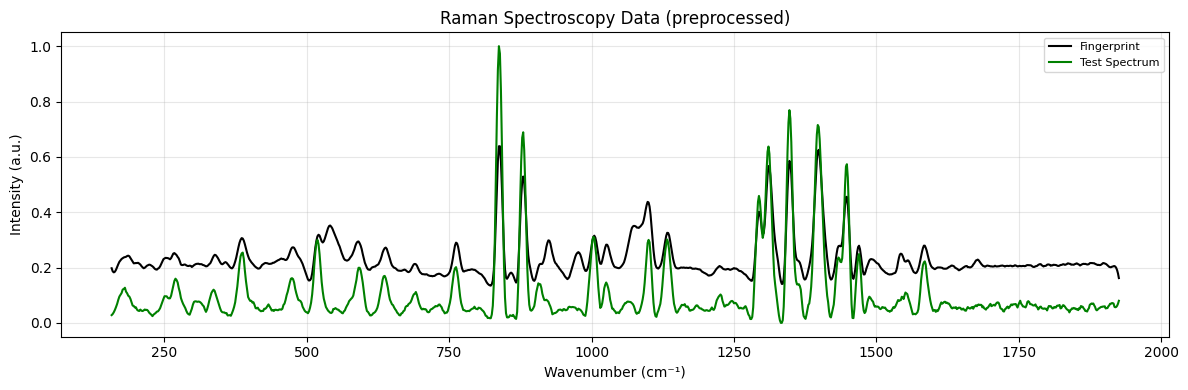

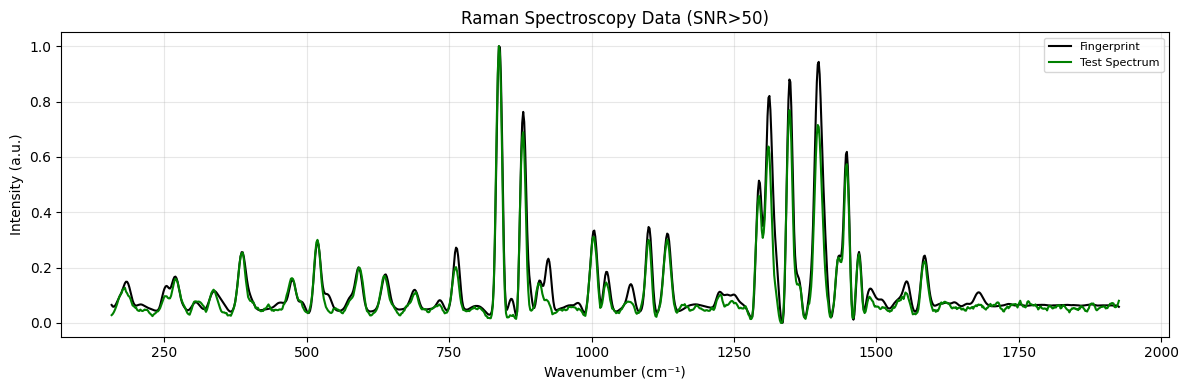

In [4]:
name = 'A+D+G'
process_pipeline(name, save_dir = Path('./data/combos3'))

## A+D+S

A+D+S: 1215 spectra loaded
Saved spectra data at data\combos3\A+D+S\raw_data.npz
Test spectrum is loaded for A+D+S
Saved test spectrum data at data\combos3\A+D+S\raw_test_spectrum.npz


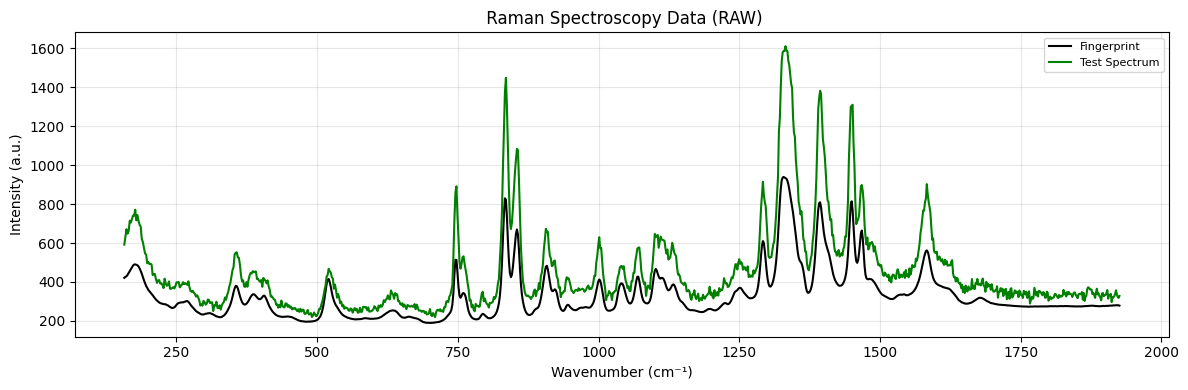

Saved preprocessed spectra data at data\combos3\A+D+S\data.npz
Saved preprocessed test spectrum data at data\combos3\A+D+S\test_spectrum.npz


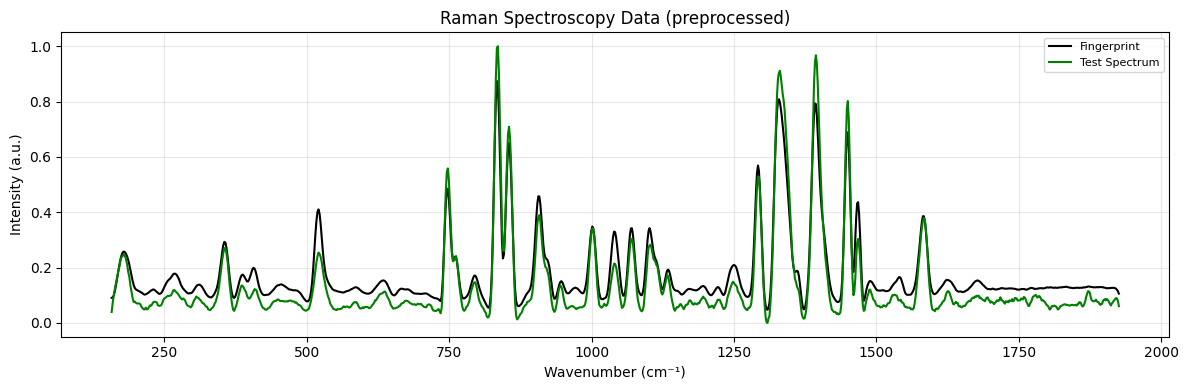

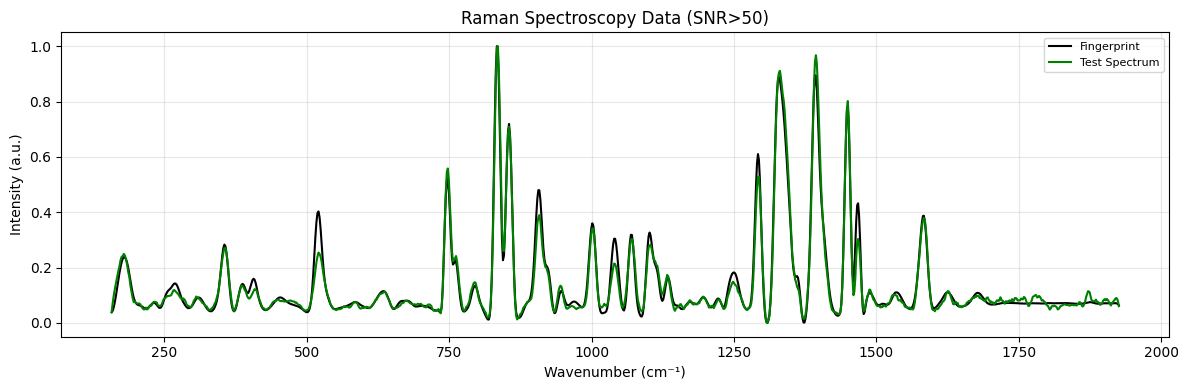

In [5]:
name = 'A+D+S'
process_pipeline(name, save_dir = Path('./data/combos3'))

## A+F+G

A+F+G: 1271 spectra loaded
Saved spectra data at data\combos3\A+F+G\raw_data.npz
Test spectrum is loaded for A+F+G
Saved test spectrum data at data\combos3\A+F+G\raw_test_spectrum.npz


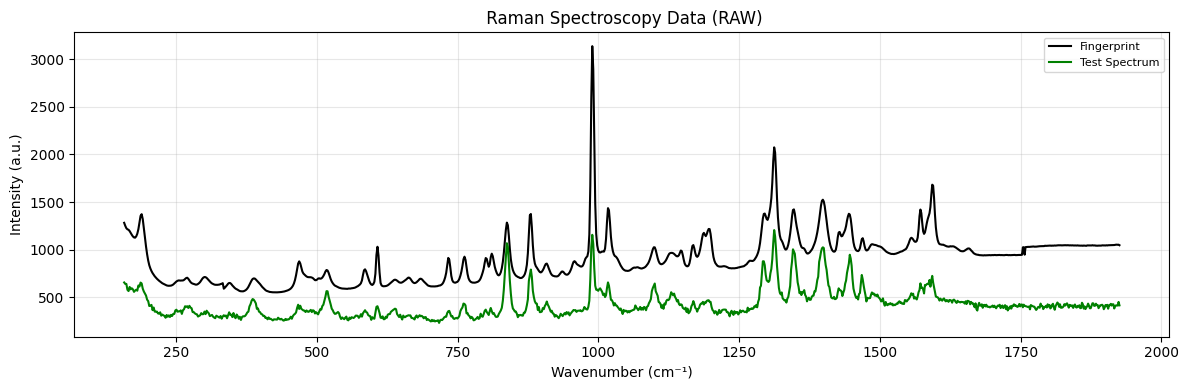

Saved preprocessed spectra data at data\combos3\A+F+G\data.npz
Saved preprocessed test spectrum data at data\combos3\A+F+G\test_spectrum.npz


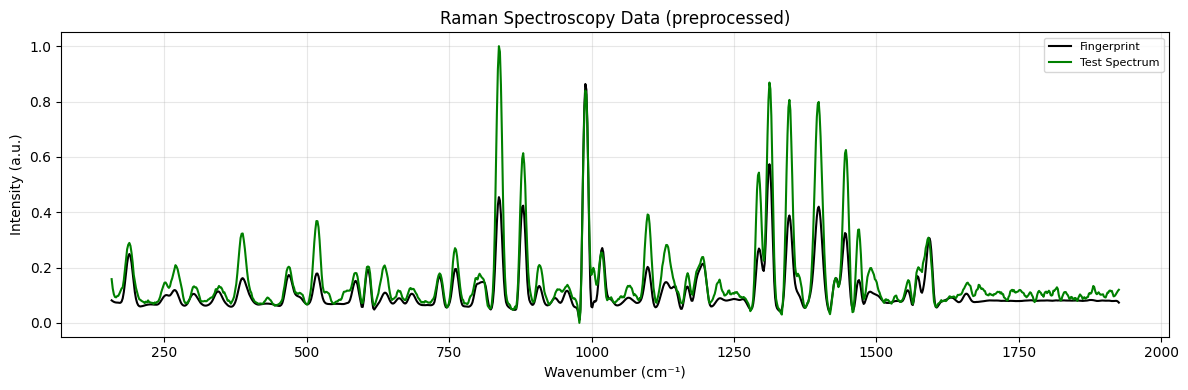

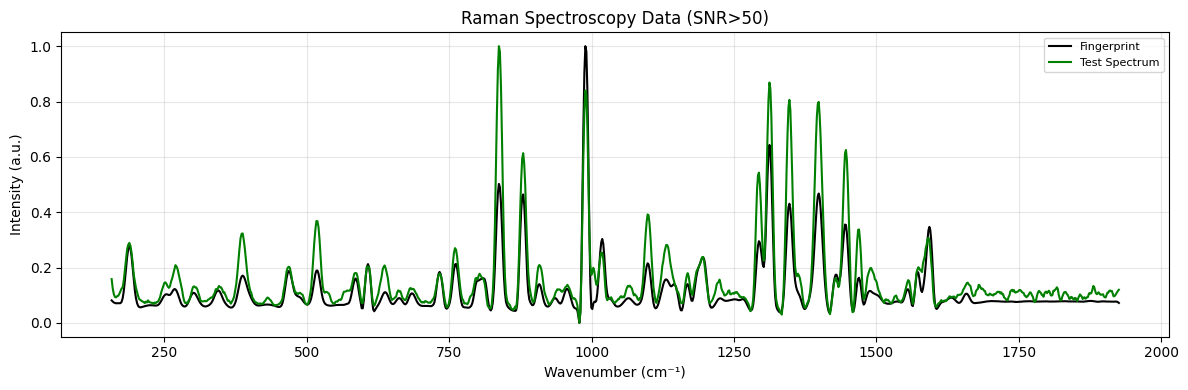

In [6]:
name = 'A+F+G'
process_pipeline(name, save_dir = Path('./data/combos3'))

## A+F+R

A+F+R: 1020 spectra loaded
Saved spectra data at data\combos3\A+F+R\raw_data.npz
Test spectrum is loaded for A+F+R
Saved test spectrum data at data\combos3\A+F+R\raw_test_spectrum.npz


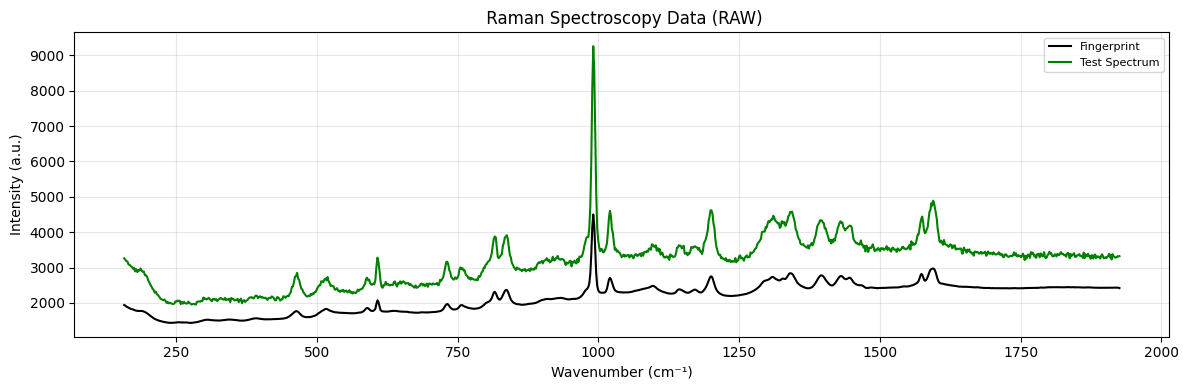

Saved preprocessed spectra data at data\combos3\A+F+R\data.npz
Saved preprocessed test spectrum data at data\combos3\A+F+R\test_spectrum.npz


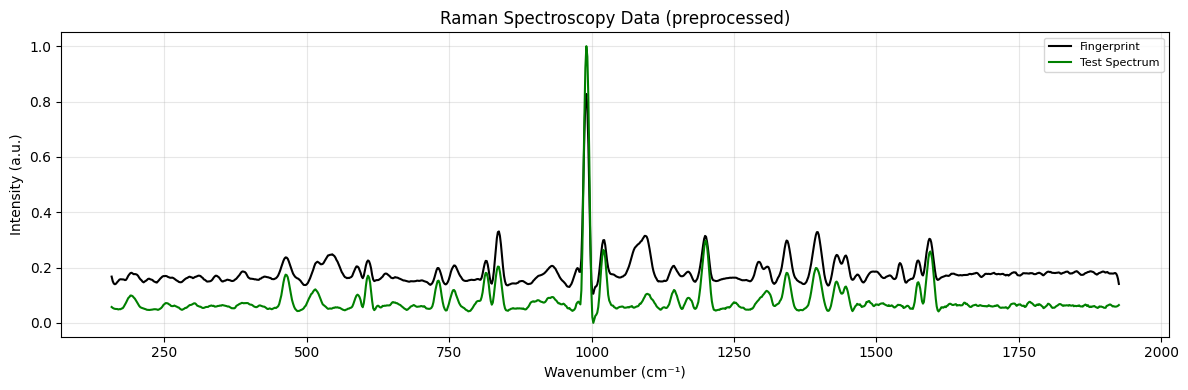

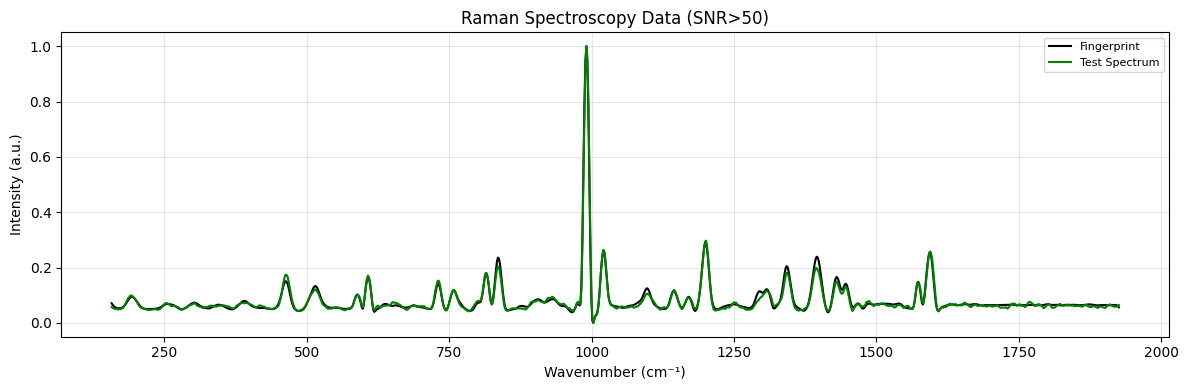

In [7]:
name = 'A+F+R'
process_pipeline(name, save_dir = Path('./data/combos3'))

## A+F+S

In [8]:
name = 'A+F+S'
process_pipeline(name, save_dir = Path('./data/combos3'))

A+F+S: Missing spectra
 Missing test spectrum for A+F+S


UnboundLocalError: cannot access local variable 'collection' where it is not associated with a value

## A+G+R

In [9]:
name = 'A+G+R'
process_pipeline(name, save_dir = Path('./data/combos3'))

A+G+R: Missing spectra
 Missing test spectrum for A+G+R


UnboundLocalError: cannot access local variable 'collection' where it is not associated with a value

## A+G+S

In [10]:
name = 'A+G+S'
process_pipeline(name, save_dir = Path('./data/combos3'))

A+G+S: Missing spectra
 Missing test spectrum for A+G+S


UnboundLocalError: cannot access local variable 'collection' where it is not associated with a value

## A+R+S

In [11]:
name = 'A+R+S'
process_pipeline(name, save_dir = Path('./data/combos3'))

A+R+S: Missing spectra
 Missing test spectrum for A+R+S


UnboundLocalError: cannot access local variable 'collection' where it is not associated with a value

# Single Amino Acid Detection from Combos
For each combo of three amino acids, assess single amino acid detection algorithm.

In [43]:
from spectra.models import convert_amino_acid, AMINO_ACID_THREE_LETTER
from spectra.data.spectraio import load_from_npz
from spectra import calculate_snr
from spectra.models import SpectralPredictor

# Load the model
save_path = 'checkpoints/spectral_transformer_final.pt'
predictor = SpectralPredictor.load(save_path)
print("Model loaded successfully!")
label_names = predictor.label_mapping

def plot_fingerprints(*spectra, title='Combos Experiment'):
    """Plot arbitrary number of fingerprints.

    Args:
        *spectra: Variable number of (fingerprint, label) tuples.
        title: Plot title (keyword argument only).

    Example:
        plot_fingerprints((fg0, 'A+D+F'), (fg1, 'alanine'), title='Combos')
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))

    colors = plt.cm.tab10.colors
    for i, item in enumerate(spectra):
        fg = item[0]
        if len(item)>1:
            label = item[1]
        else:
            label = 'fingerprint'
        if len(item) > 2:
            color = item[2]
        else:
            color = colors[i % len(colors)]

        if len(item) > 3:
            alpha = item[3]
        else:
            alpha = 1.0 if i == 0 else 0.6
        ax1.plot(fg.wavelengths, fg.intensities,
                 '-', color=color, linewidth=2, alpha=alpha, label=label)

    ax1.set_xlabel('Wavenumber (cm⁻¹)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Model loaded successfully!


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [44]:
# define a pipeline for three amino acid mixtures
def process_mixed_amino_acids(name, snr_threshold=30):
    # Parse three amino acids from name (e.g., 'A+D+F')
    parts = name.split('+')
    aa1 = convert_amino_acid(parts[0], "full")
    aa2 = convert_amino_acid(parts[1], "full")
    aa3 = convert_amino_acid(parts[2], "full")
    
    # Find class indices
    cls1, cls2, cls3 = None, None, None
    for key, value in label_names.items():
        if aa1 == value:
            cls1 = key
        if aa2 == value:
            cls2 = key
        if aa3 == value:
            cls3 = key
    
    print(f'{name}')
    print(f'{aa1}({cls1})\t{aa2}({cls2})\t{aa3}({cls3})\n')
    
    # read fingerprints
    fg1 = load_from_npz(Path('./data/monopeptide/') / aa1 / 'fingerprint.npz')[0]
    fg1 = normalize_minmax(fg1)
    fg2 = load_from_npz(Path('./data/monopeptide/') / aa2 / 'fingerprint.npz')[0]
    fg2 = normalize_minmax(fg2)
    fg3 = load_from_npz(Path('./data/monopeptide/') / aa3 / 'fingerprint.npz')[0]
    fg3 = normalize_minmax(fg3)
    
    # read combos data
    collection = load_from_npz(Path('./data/combos3/') / name / 'data.npz')
    snr_values = calculate_snr(collection)
    
    idx_data = np.where(snr_values > snr_threshold)[0]
    
    print('Summary:\n')
    print(f'Number of Spectra: {len(collection)}')
    print(f'Number of Noisy Spectra (SNR < {snr_threshold}): {len(collection)-len(idx_data)}')
    print(f'Number of Clean Spectra (SNR >= {snr_threshold}): {len(idx_data)}')
    
    # classify samples - only first prediction
    results = []
    for id0 in idx_data:
        fg0 = collection[id0]
        probs = predictor.predict_proba(fg0.intensities)[0]
        predicted_cls_id = np.argmax(probs)
        result = {'id': id0,
                  'snr': snr_values[id0],
                  'prob': probs[predicted_cls_id],
                  'label': predicted_cls_id
                 }
        results.append(result)

    # plot histogram of first predictions
    first_amino = [r['label'] for r in results]
    counts = np.bincount(first_amino, minlength=19)
    x = np.arange(19)
    plt.bar(x, counts, label='First Likely Amino Acid')
    plt.xticks(x, [n.capitalize() for n in label_names.values()], rotation=90)
    plt.legend(loc='upper right', fontsize=12)
    plt.title(f'{name} - First Prediction Distribution')
    plt.tight_layout()
    plt.show()

    # Show example spectra for each detected amino acid
    first_amino = np.array([r['label'] for r in results])
    max_p = np.array([r['prob'] for r in results])
    
    for cls_id, aa_name in [(cls1, aa1), (cls2, aa2), (cls3, aa3)]:
        if cls_id is None:
            continue
        filter_idx = np.where(np.logical_and(first_amino == cls_id, max_p > 0.7))[0]
        if len(filter_idx) > 0:
            id0 = results[filter_idx[0]]['id']
            fg0 = collection[id0]
            
            # plot samples
            plot_fingerprints(
                (fg0, name),
                (fg1, aa1),
                (fg2, aa2),
                (fg3, aa3),
                title=f'Most likely {aa_name.capitalize()} (p={results[filter_idx[0]]["prob"]:.2f})'
            )
            print(f'{label_names[results[filter_idx[0]]["label"]].capitalize()}: {results[filter_idx[0]]["prob"]:.3f}')
    
    return results

A+D+F
alanine(0)	aspartic acid(3)	phenylalanine(12)

Summary:

Number of Spectra: 1302
Number of Noisy Spectra (SNR < 30): 295
Number of Clean Spectra (SNR >= 30): 1007


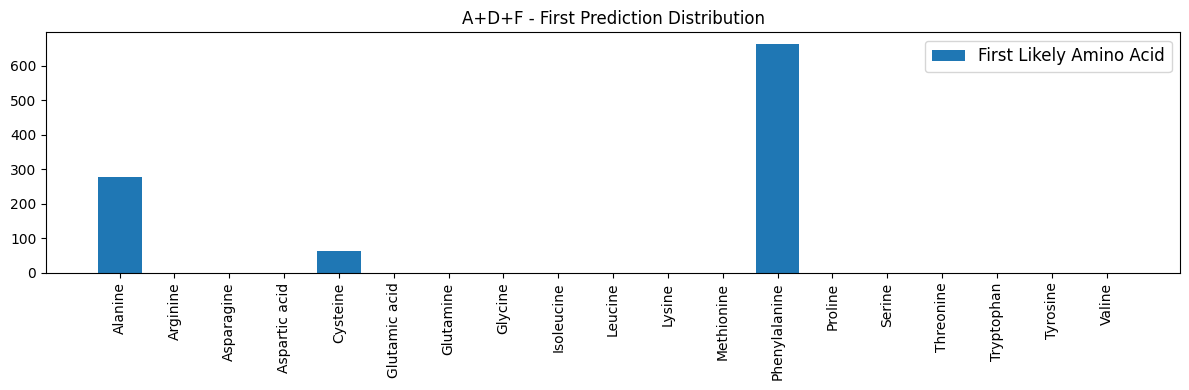

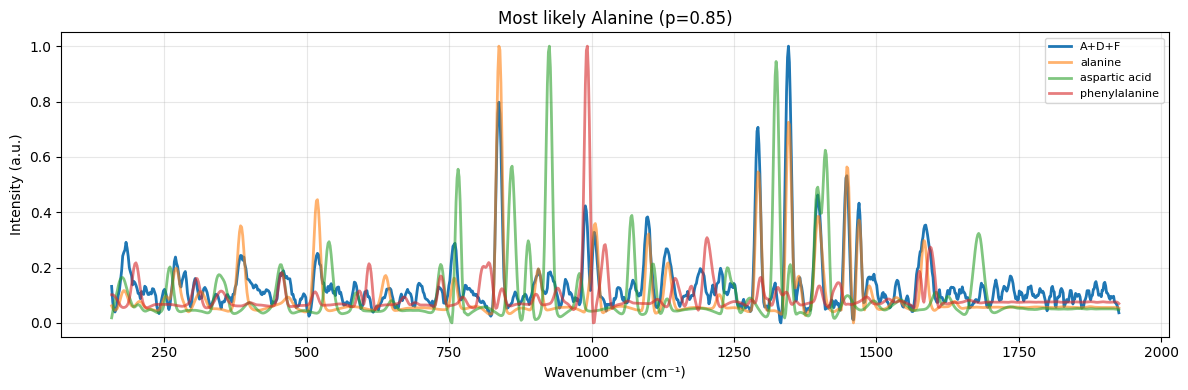

Alanine: 0.853


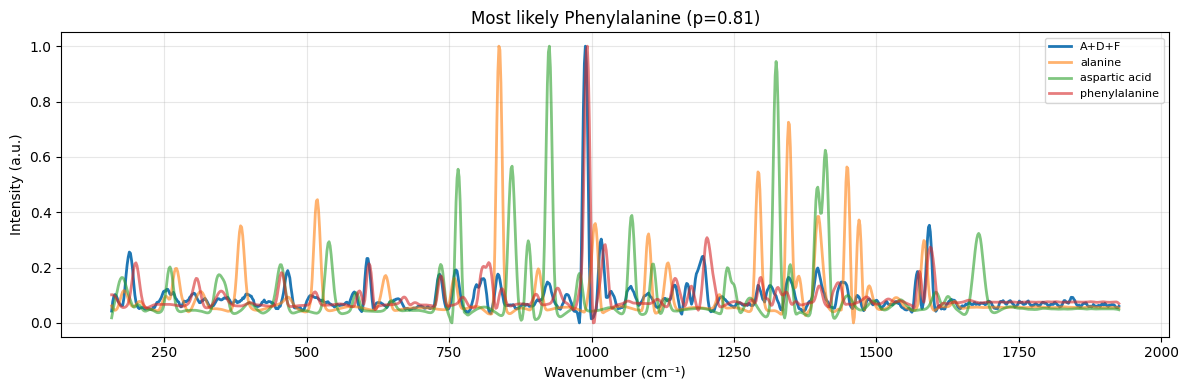

Phenylalanine: 0.806


In [45]:
name = 'A+D+F'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

A+D+G
alanine(0)	aspartic acid(3)	glycine(7)

Summary:

Number of Spectra: 1334
Number of Noisy Spectra (SNR < 30): 631
Number of Clean Spectra (SNR >= 30): 703


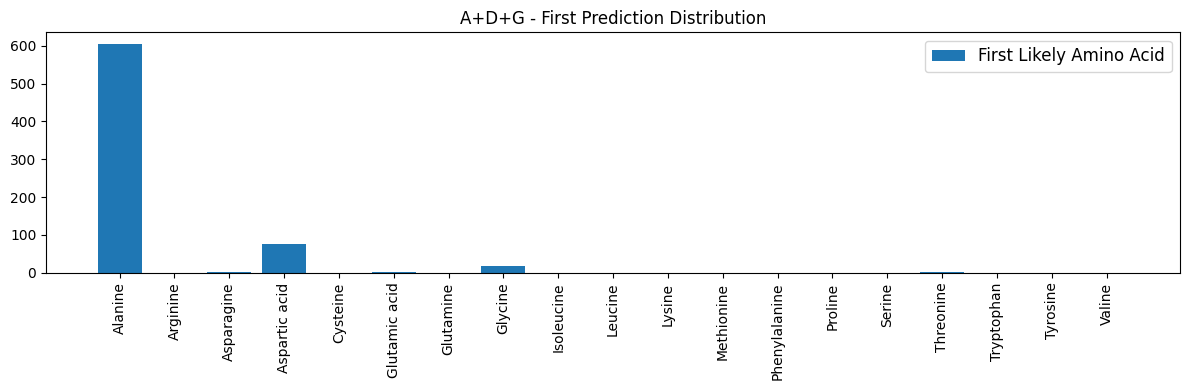

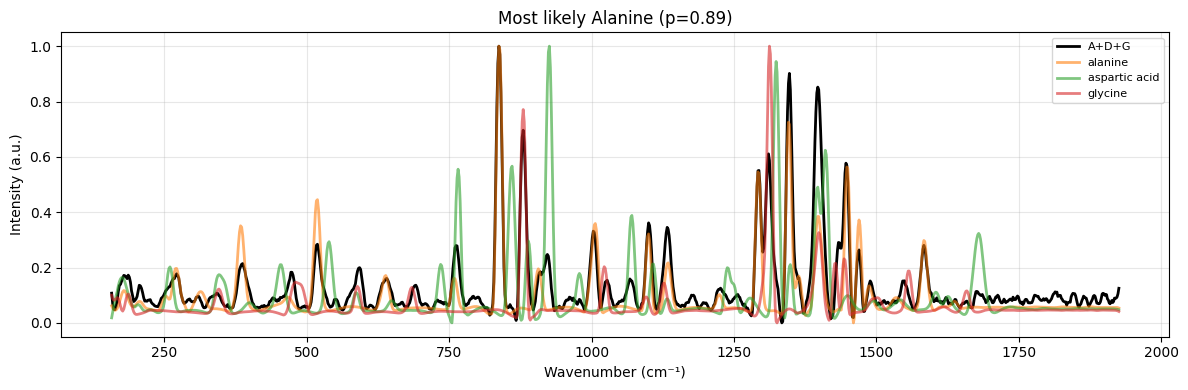

Alanine: 0.892


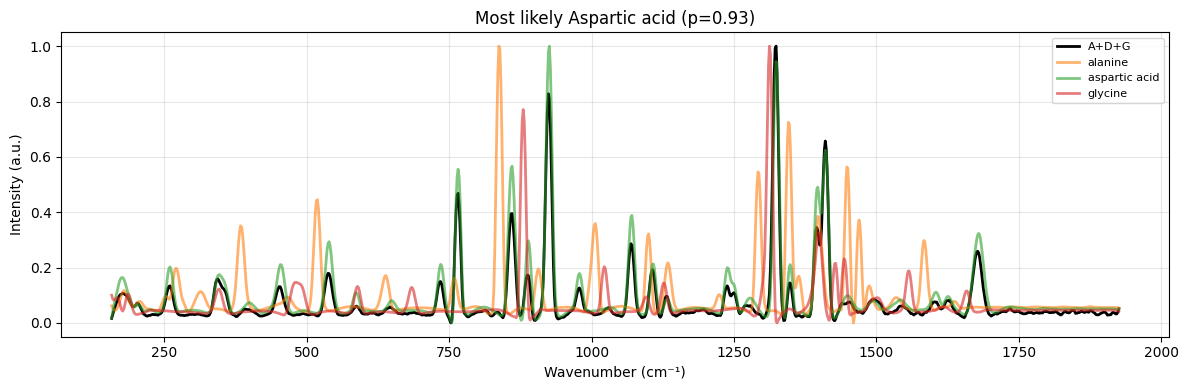

Aspartic acid: 0.931


In [15]:
name = 'A+D+G'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

A+D+S
alanine(0)	aspartic acid(3)	serine(14)

Summary:

Number of Spectra: 1215
Number of Noisy Spectra (SNR < 30): 253
Number of Clean Spectra (SNR >= 30): 962


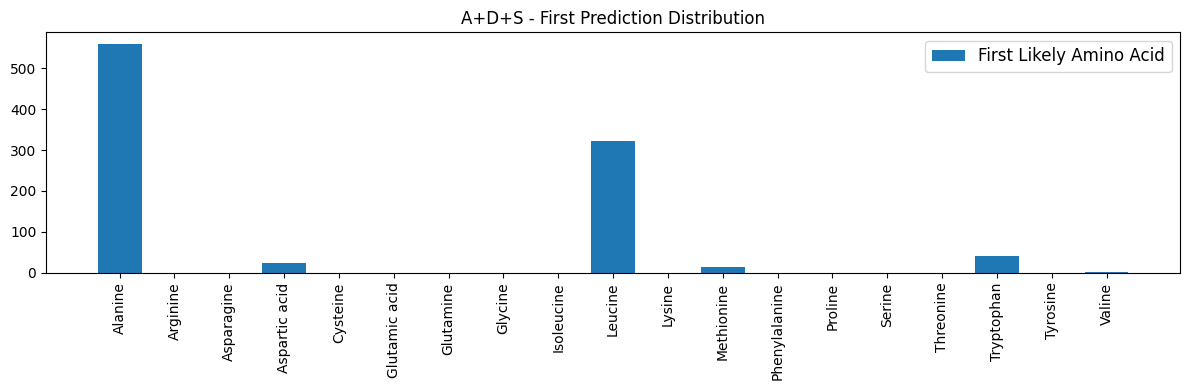

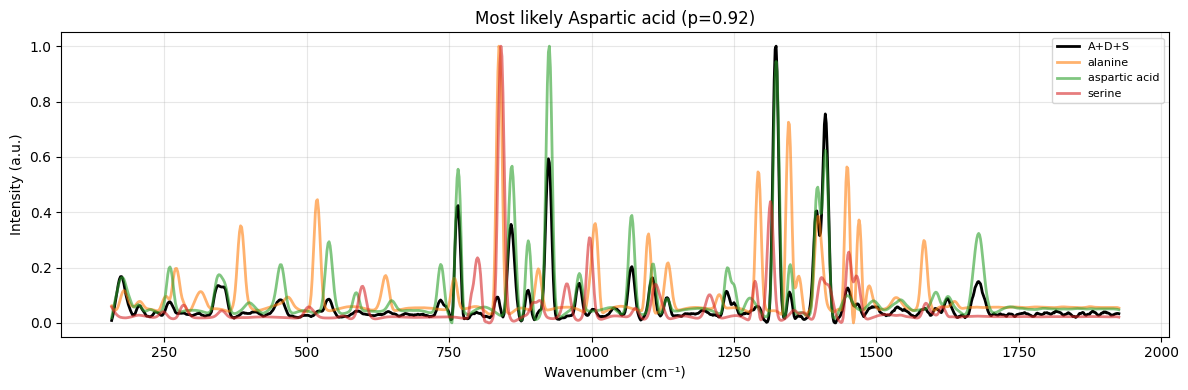

Aspartic acid: 0.921


In [16]:
name = 'A+D+S'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

A+F+G
alanine(0)	phenylalanine(12)	glycine(7)

Summary:

Number of Spectra: 1271
Number of Noisy Spectra (SNR < 30): 52
Number of Clean Spectra (SNR >= 30): 1219


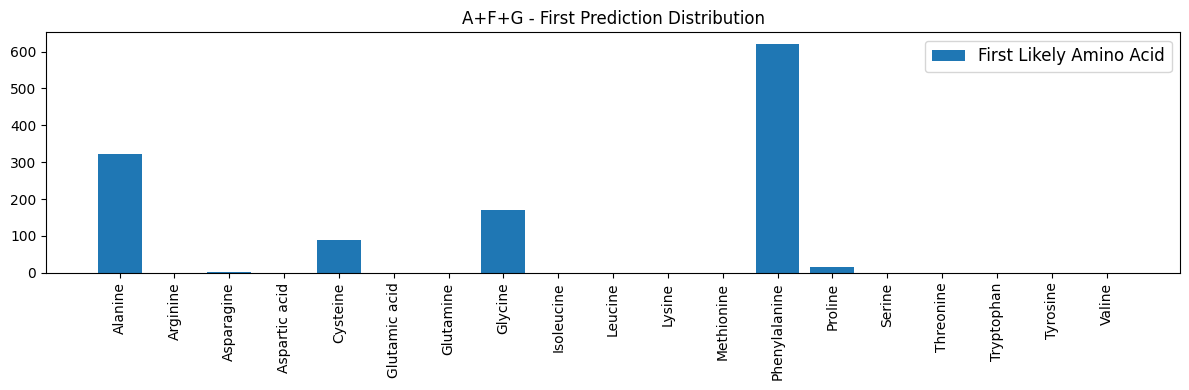

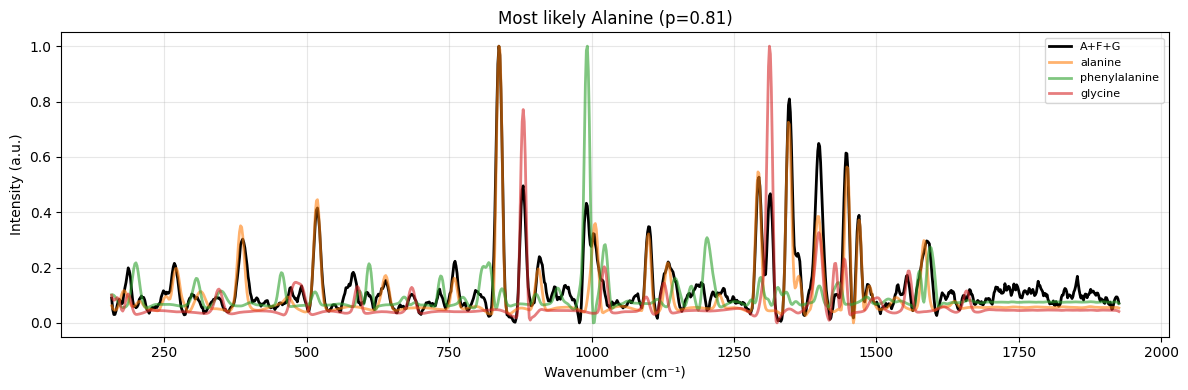

Alanine: 0.813


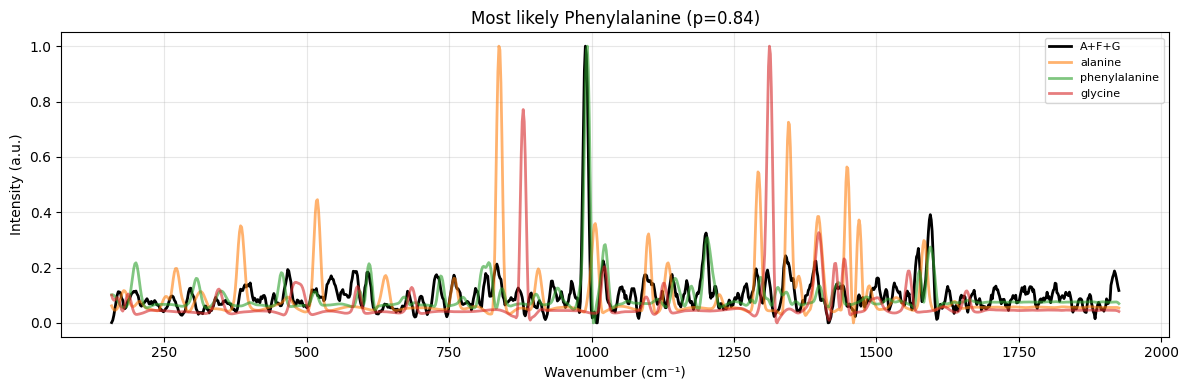

Phenylalanine: 0.838


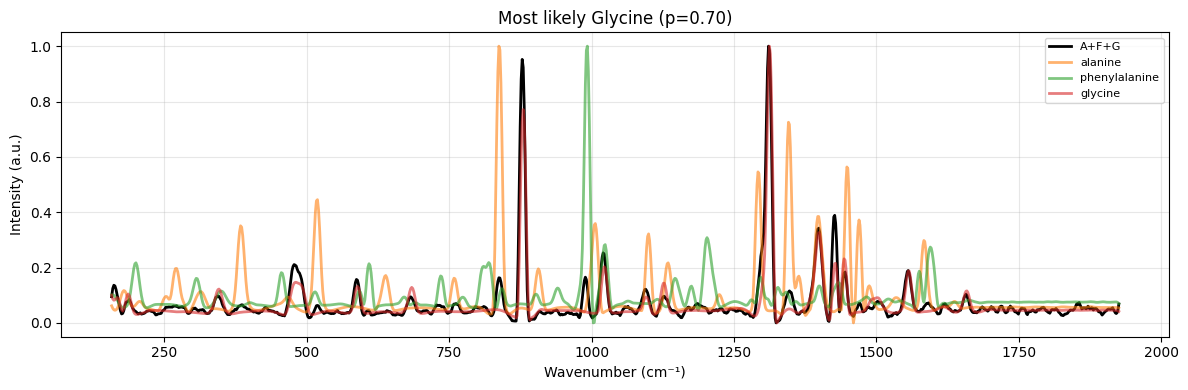

Glycine: 0.702


In [17]:
name = 'A+F+G'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

A+F+R
alanine(0)	phenylalanine(12)	arginine(1)

Summary:

Number of Spectra: 1020
Number of Noisy Spectra (SNR < 30): 401
Number of Clean Spectra (SNR >= 30): 619


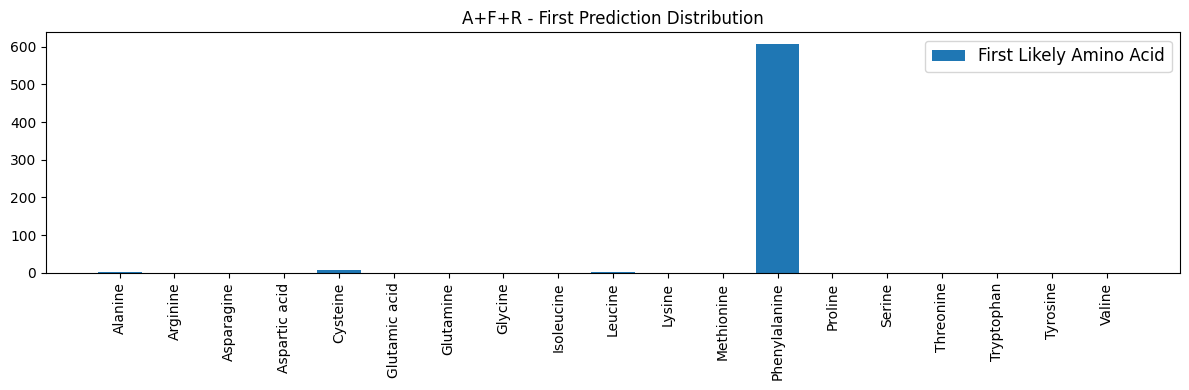

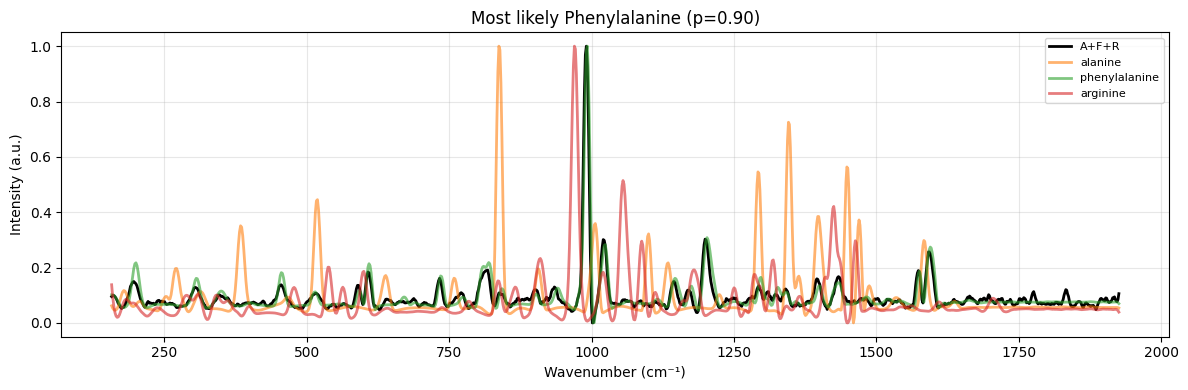

Phenylalanine: 0.904


In [18]:
name = 'A+F+R'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

# Superposition of single amino acids v.s. mixture signal
Estimate mixture weights (alpha, beta) such that alpha*fg1 + beta*fg2 + (1-alpha-beta)*fg3 approximates the measured mixture.

In [46]:
from scipy.optimize import minimize

def estimate_mixture_weights(fg0, fg1, fg2, fg3):
    """
    Estimate optimal mixture weights alpha, beta such that
    alpha*fg1 + beta*fg2 + (1-alpha-beta)*fg3 is closest to fg0.

    Args:
        fg0: Mixture spectrum (Spectrum object)
        fg1: First amino acid fingerprint (Spectrum object)
        fg2: Second amino acid fingerprint (Spectrum object)
        fg3: Third amino acid fingerprint (Spectrum object)

    Returns:
        (alpha, beta): Mixing weights where gamma = 1 - alpha - beta
    """
    y0 = fg0.intensities
    y1 = fg1.intensities
    y2 = fg2.intensities
    y3 = fg3.intensities

    def loss(params):
        alpha, beta = params
        gamma = 1 - alpha - beta
        y_pred = alpha * y1 + beta * y2 + gamma * y3
        # Min-max normalization to [0, 1]
        y_pred = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
        return np.mean(np.abs(y0 - y_pred))  # MAE loss

    # Constraints: alpha >= 0, beta >= 0, alpha + beta <= 1
    constraints = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}
    bounds = [(0, 1), (0, 1)]

    result = minimize(loss, x0=[0.33, 0.33], method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x[0], result.x[1]

In [57]:
def conv_amino_acids(name, snr_threshold=30):
    # Parse three amino acids from name (e.g., 'A+D+F')
    parts = name.split('+')
    aa1 = convert_amino_acid(parts[0], "full")
    aa2 = convert_amino_acid(parts[1], "full")
    aa3 = convert_amino_acid(parts[2], "full")
    
    print(f'{name}')
    print(f'{aa1}\t{aa2}\t{aa3}\n')
    
    # read fingerprints
    fg1 = load_from_npz(Path('./data/monopeptide/') / aa1 / 'fingerprint.npz')[0]
    fg1 = normalize_minmax(fg1)
    fg2 = load_from_npz(Path('./data/monopeptide/') / aa2 / 'fingerprint.npz')[0]
    fg2 = normalize_minmax(fg2)
    fg3 = load_from_npz(Path('./data/monopeptide/') / aa3 / 'fingerprint.npz')[0]
    fg3 = normalize_minmax(fg3)
    
    # read combos data
    collection = load_from_npz(Path('./data/combos3/') / name / 'data.npz')
    snr_values = calculate_snr(collection)
    
    idx_data = np.where(snr_values > snr_threshold)[0]
    
    print('Summary:\n')
    print(f'Number of Spectra: {len(collection)}')
    print(f'Number of Noisy Spectra (SNR < {snr_threshold}): {len(collection)-len(idx_data)}')
    print(f'Number of Clean Spectra (SNR >= {snr_threshold}): {len(idx_data)}')
    
    # classify samples and estimate mixture weights
    results = []
    for id0 in idx_data:
        fg0 = collection[id0]
        alpha, beta = estimate_mixture_weights(fg0, fg1, fg2, fg3)
        probs = predictor.predict_proba(fg0.intensities)[0]
        predicted_cls_id = np.argmax(probs)
        result = {'id': id0,
                  'snr': snr_values[id0],
                  'prob': probs[predicted_cls_id],
                  'label': predicted_cls_id,
                  'alpha': alpha,
                  'beta': beta,
                  'gamma': 1 - alpha - beta
                 }
        results.append(result)
    
    # Find a sample with balanced mixture
    max_p = np.array([r['prob'] for r in results])
    betas = np.array([r['beta'] for r in results])
    #filter_idx = np.where(0.3< betas)[0]
    filter_idx = [np.abs(betas - 0.3).argmin()]
    
    if len(filter_idx) > 0:
        result = results[filter_idx[0]]
        id0 = result['id']
        alpha, beta = result['alpha'], result['beta']
        gamma = result['gamma']
        fg0 = collection[id0]
        
        print(f'Sample {id0}: alpha={alpha:.3f}, beta={beta:.3f}, gamma={gamma:.3f}')
        
        # Compute superposition of three fingerprints
        fgc_intensities = alpha * fg1.intensities + beta * fg2.intensities + gamma * fg3.intensities
        fgc_intensities = (fgc_intensities - fgc_intensities.min()) / (fgc_intensities.max() - fgc_intensities.min())
        fgc = Spectrum(np.stack((fg1.wavelengths, fgc_intensities), axis=1))

        # plot just measured vs superposition
        plot_fingerprints(
            (fg0, f'{name} (measured)', 'k', 1),
            (fgc, f'{name} (superposition)', 'c', 0.6),
            title=f'Mixture vs Superposition (α={alpha:.2f}, β={beta:.2f}, γ={gamma:.2f})'
        )
        
        # plot measured vs superposition
        plot_fingerprints(
            (fg1, aa1, 'r', 0.6),
            (fg2, aa2, 'g', 0.6),
            (fg3, aa3, 'b', 0.6),
            title=f'Fingerprints: {name}'
        )
        
        
    
    return results

A+D+F
alanine	aspartic acid	phenylalanine

Summary:

Number of Spectra: 1302
Number of Noisy Spectra (SNR < 50): 493
Number of Clean Spectra (SNR >= 50): 809
Sample 1273: alpha=0.338, beta=0.328, gamma=0.334


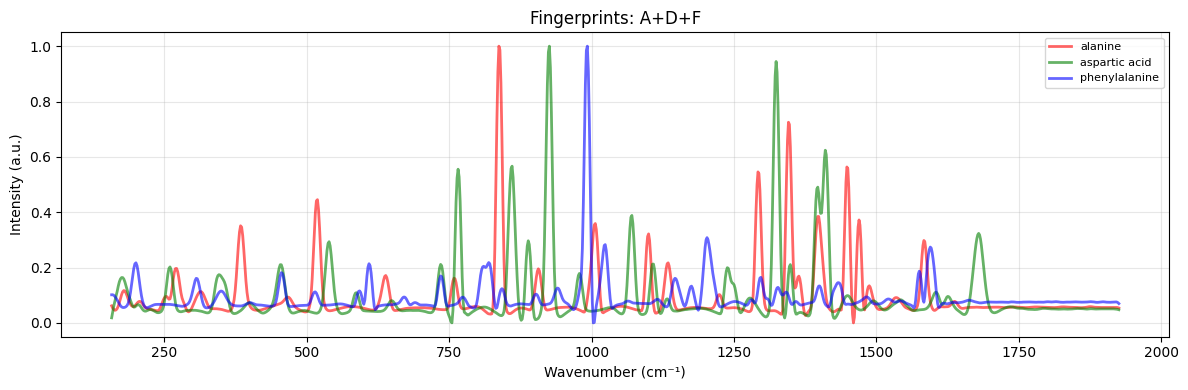

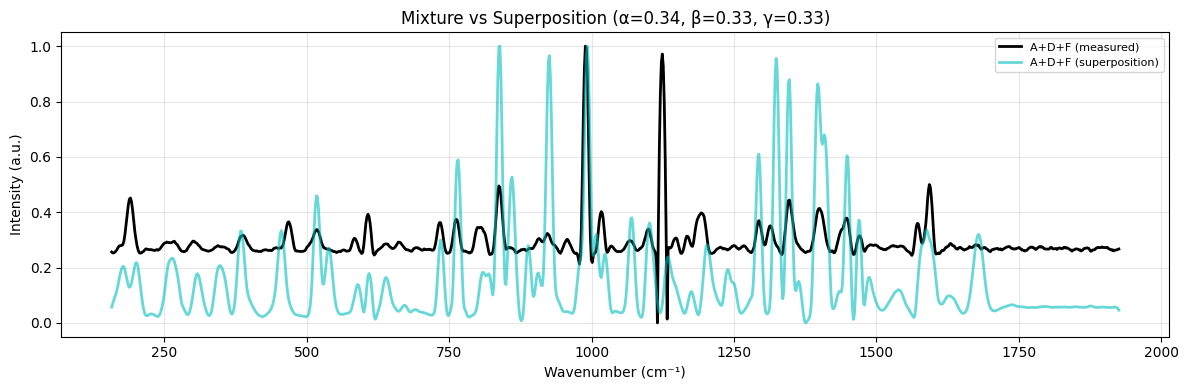

In [55]:
name = 'A+D+F'
snr_threshold = 50
results = conv_amino_acids(name, snr_threshold)

A+F+G
alanine	phenylalanine	glycine

Summary:

Number of Spectra: 1271
Number of Noisy Spectra (SNR < 30): 52
Number of Clean Spectra (SNR >= 30): 1219
Sample 725: alpha=0.328, beta=0.300, gamma=0.372


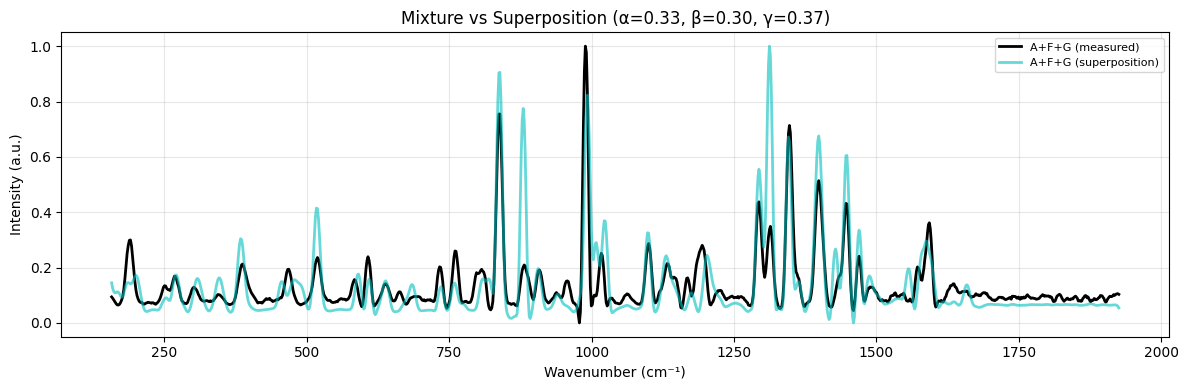

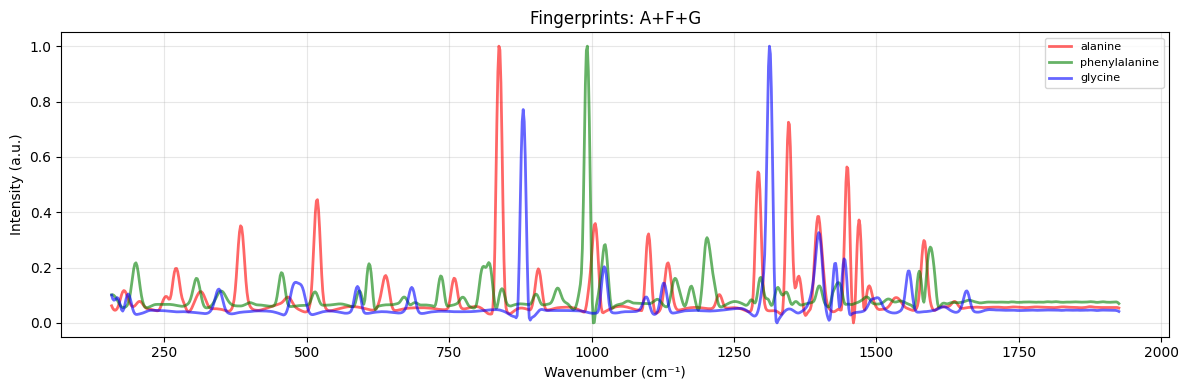

In [59]:
name = 'A+F+G'
snr_threshold = 30
results = conv_amino_acids(name, snr_threshold)

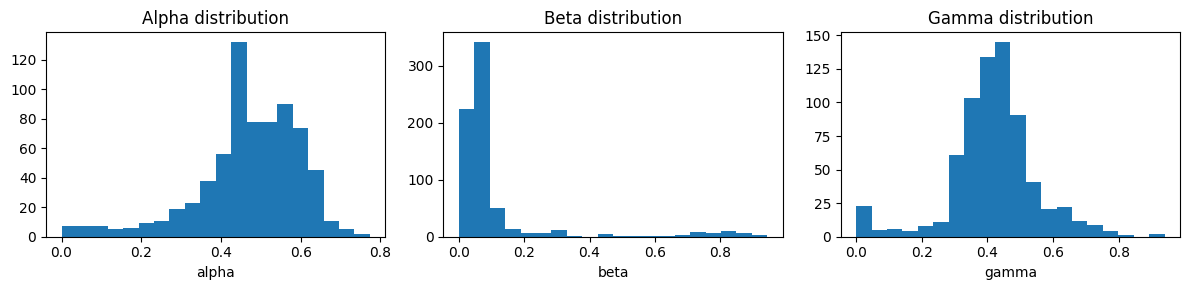

In [23]:
# Plot distribution of mixture weights
alpha = np.array([r['alpha'] for r in results])
beta = np.array([r['beta'] for r in results])
gamma = np.array([r['gamma'] for r in results])

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(alpha, bins=20)
axes[0].set_title('Alpha distribution')
axes[0].set_xlabel('alpha')
axes[1].hist(beta, bins=20)
axes[1].set_title('Beta distribution')
axes[1].set_xlabel('beta')
axes[2].hist(gamma, bins=20)
axes[2].set_title('Gamma distribution')
axes[2].set_xlabel('gamma')
plt.tight_layout()
plt.show()